# Théo COUERBE — MIAM TP Identification

## Introduction

Ce TP porte sur l'identification de la perméabilité dans un milieu poreux inhomogène. On résout l'équation de Darcy par éléments finis :

$$\begin{cases}
\text{div}(k\,\text{grad}(p)) = 0 & \text{dans } \Omega \\
k\frac{\partial p}{\partial n} = V_n & \text{sur } \Gamma_n \\
p = U_d & \text{sur } \Gamma_d
\end{cases}$$

Le domaine $\Omega$ est un carré avec 4 buses d'injection. Il est séparé en deux sous-domaines $\Omega_1$ et $\Omega_2$ (un disque central) de perméabilités respectives $k_1$ et $k_2$. L'objectif est de retrouver $(k_1, k_2) = (1, 2)$ à partir de mesures de débits entrants $\phi_i$ et de pressions $P_i$.

On utilise la méthode d'identification par substitution (Newton) avec calcul des sensibilités par différences finies.

## 1. Utilisation du code de calcul éléments finis

### 1.1 Import des bibliothèques et chargement du maillage

In [1]:
import sys
sys.path.insert(0, '.')

import tp_identification_ressources as tir
import donnees_identification.my_gmshparser as gmp
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spl
import matplotlib.pyplot as plt

# Chargement du maillage
mesh = gmp.parse('meshes/quad_sb.msh')
print(f'Noeuds: {mesh.get_number_of_nodes()}')
for e in mesh.get_element_entities():
    if e.get_element_type() == 2:
        print(f'  Domaine {e.get_tag()}: {e.get_number_of_elements()} triangles')

# Pré-calcul des matrices élémentaires (fait une seule fois)
ind, jnd, Kel, elset = tir.ElMats(mesh)

Noeuds: 803
  Domaine 1: 1060 triangles
  Domaine 2: 376 triangles


### 1.2 Extraction des mesures

In [2]:
# Mesures inhomogènes (k1=1, k2=2)
phi1, phi2, phi3, phi4, um, Pi, Pm = tir.readMeasurement(
    'measurements/measure_sb.npz', 'measurements/measure_sb_Pi.npz')
phi = np.array([phi1, phi2, phi3, phi4])

# Mesures homogènes (k=1)
phi1_h, phi2_h, phi3_h, phi4_h, um_h, Pi_h, Pm_h = tir.readMeasurement(
    'measurements/measure_sb_H.npz', 'measurements/measure_sb_Pi_H.npz')
phi_h = np.array([phi1_h, phi2_h, phi3_h, phi4_h])

print('=== Mesures inhomogènes ===')
print(f'phi = ({phi1:.6f}, {phi2:.6f}, {phi3:.6f}, {phi4:.6f})')
print(f'Pm  = {Pm.flatten()}')
print(f'um shape = {um.shape}, min={um.min():.4f}, max={um.max():.4f}')

print('\n=== Mesures homogènes ===')
print(f'phi = ({phi1_h:.6f}, {phi2_h:.6f}, {phi3_h:.6f}, {phi4_h:.6f})')
print(f'Pm  = {Pm_h.flatten()}')
print(f'um shape = {um_h.shape}, min={um_h.min():.4f}, max={um_h.max():.4f}')

=== Mesures inhomogènes ===
phi = (0.195499, -0.066576, -0.062365, -0.066559)
Pm  = [1. 0. 0. 0.]
um shape = (803,), min=0.0000, max=1.0000

=== Mesures homogènes ===
phi = (0.188978, -0.065359, -0.058284, -0.065335)
Pm  = [1. 0. 0. 0.]
um shape = (803,), min=0.0000, max=1.0000


### 1.3 Affichage du champ $u_m$

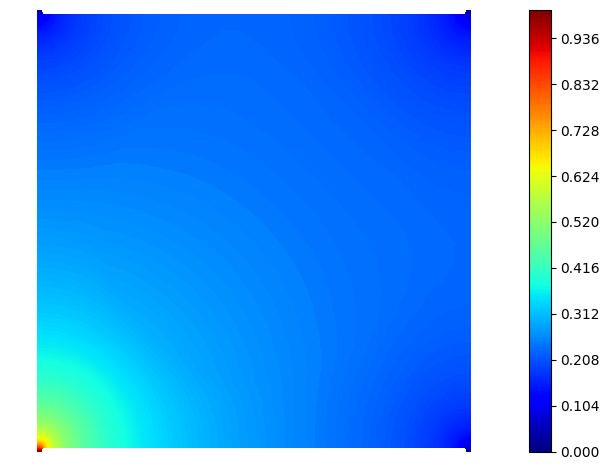

In [3]:
tir.plotMesh(mesh, U=um, rmin=0, rmax=1)

Le champ de pression varie de $P=0$ sur les buses 2,3,4 à $P=1$ sur la buse 1. Le disque central (moins perméable si $k_2 < k_1$) perturbe l'écoulement.

### 1.4 Fonction de calcul direct (Neumann + Dirichlet ponctuel + translation)

On construit une fonction qui résout le problème avec conditions de Neumann (flux imposés aux buses) et une condition de Dirichlet ponctuelle ($p=0$ au nœud 0) pour fixer la constante.

Le flux normal imposé sur chaque buse est $V_i = \frac{\phi_i}{L}$ où $L = 0.02\,\text{mm}$.

Ensuite on applique une translation pour recaler la solution sur les mesures :

$$t = \frac{1}{4}\sum_{i=1}^{4}\left([\Pi u_m]_i - [\Pi p]_i\right)$$

$$p_t = p + t$$

In [4]:
L = 0.02  # largeur d'une buse (mm)

def calcul_direct(mesh, k1, k2, phis, ind, jnd, Kel, elset):
    """
    Calcul direct EF avec conditions de Neumann aux 4 buses.
    Retourne le champ de pression p.
    """
    neumanndict = {1: phis[0]/L, 2: phis[1]/L, 3: phis[2]/L, 4: phis[3]/L}
    paramdict = {1: k1, 2: k2}
    K0 = tir.assemK(mesh, ind, jnd, Kel, elset, paramdict)
    f0 = tir.NeumannNormal(mesh, neumanndict)
    C, d = tir.DirichletScalar(mesh, {}, zerozero=True)
    K, f = tir.minCstr(K0, f0, C, d)
    p = tir.spl.spsolve(K, f)
    return p

def translation(p, Pi, Pm):
    """
    Translation optimale : min_t ||Pi um - Pi(p + t)||^2.
    Solution analytique : t = moyenne(Pi um - Pi p).
    """
    Pi_p = Pi @ p
    Pm_f = Pm.flatten()
    t = np.sum(Pm_f - Pi_p) / 4.0
    return p + t

### 1.5 Test de la fonction de calcul direct avec les vrais paramètres

In [5]:
# Cas inhomogène : k1=1, k2=2
p_inhomo = calcul_direct(mesh, 1.0, 2.0, phi, ind, jnd, Kel, elset)
pt_inhomo = translation(p_inhomo, Pi, Pm)
Pi_pt = Pi @ pt_inhomo
residu_inhomo = np.linalg.norm(Pi_pt - Pm.flatten())

print(f'Pi@pt = {Pi_pt}')
print(f'Pm    = {Pm.flatten()}')
print(f'Résidu ||Pi@pt - Pm|| = {residu_inhomo:.2e}')

# Cas homogène : k=1
p_homo = calcul_direct(mesh, 1.0, 1.0, phi_h, ind, jnd, Kel, elset)
pt_homo = translation(p_homo, Pi_h, Pm_h)
Pi_pt_h = Pi_h @ pt_homo
residu_homo = np.linalg.norm(Pi_pt_h - Pm_h.flatten())

print(f'\nCas homogène (k=1): résidu = {residu_homo:.2e}')

Pi@pt = [ 1.00005373e+00 -1.83233070e-05 -1.71098712e-05 -1.82961991e-05]
Pm    = [1. 0. 0. 0.]
Résidu ||Pi@pt - Pm|| = 6.20e-05

Cas homogène (k=1): résidu = 6.00e-05


### 1.6 Comparaison avec $u_m$

On compare la solution obtenue par calcul direct (Neumann) avec le champ de mesure $u_m$ (généré par conditions de Dirichlet).

||um - pt|| = 0.0079
max|um - pt| = 0.0035


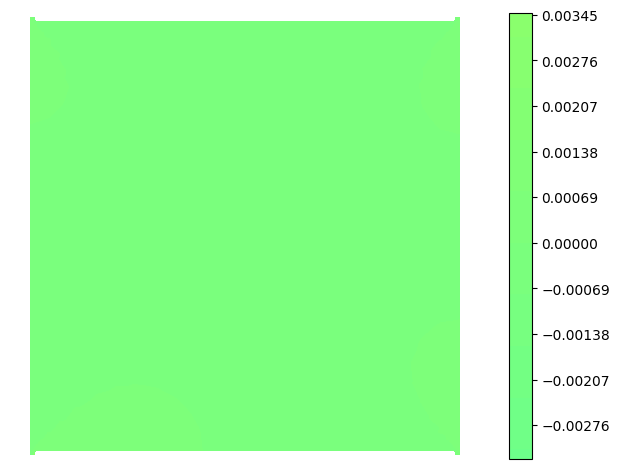

In [6]:
diff = um - pt_inhomo
print(f'||um - pt|| = {np.linalg.norm(diff):.4f}')
print(f'max|um - pt| = {np.max(np.abs(diff)):.4f}')

tir.plotMesh(mesh, U=diff, rmin=-0.1, rmax=0.1)

**La solution n'est pas parfaitement égale à $u_m$.**

La mesure $u_m$ a été générée avec des conditions de Dirichlet (pressions imposées $P_1=1$, $P_2=P_3=P_4=0$), alors que notre calcul direct utilise des conditions de Neumann (flux mesurés $\phi_i$). Ce sont deux problèmes aux limites différents. La translation ne corrige qu'un décalage constant. La forme du champ est donc légèrement différente.

**Conséquence sur l'identification** : le résidu $\|\Pi p - P_m\|$ ne sera jamais nul, même avec les vrais paramètres. On cherchera le minimum atteignable, qui correspondra aux meilleurs paramètres identifiables dans ce cadre Neumann.

## 2. Identification par substitution (méthode des sensibilités)

On implémente l'algorithme de Newton (algorithme 1 du sujet).

À chaque itération, on calcule la jacobienne $J$ par différences finies :

$$J_d = \frac{p(\tilde{k}_d) - p(k)}{\varepsilon}, \quad \tilde{k}_d = k + \varepsilon e_d$$

Puis la sensibilité $S = \Pi J$, le gradient $g = S^T(\Pi p - P_m)$ et la hessienne $H = S^T S$.

Mise à jour : $k \leftarrow k - H^{-1} g$.

### 2.1 Cas à un paramètre (milieu homogène)

On utilise les mesures homogènes (`measure_sb_H`). La valeur de référence est $k_{\text{ref}} = 1$.

In [7]:
def identification_1param(k0, eps=0.01, max_iter=15, tol=1e-10):
    """Identification Newton à 1 paramètre."""
    k = k0
    k_hist, res_hist, err_hist = [], [], []
    Pm_f = Pm_h.flatten()
    
    for it in range(max_iter):
        p0 = calcul_direct(mesh, k, k, phi_h, ind, jnd, Kel, elset)
        p0t = translation(p0, Pi_h, Pm_h)
        residu = np.linalg.norm(Pi_h @ p0t - Pm_f)
        erreur = abs(k - 1.0)
        k_hist.append(k)
        res_hist.append(residu)
        err_hist.append(erreur)
        
        # Perturbation
        pd = calcul_direct(mesh, k+eps, k+eps, phi_h, ind, jnd, Kel, elset)
        pdt = translation(pd, Pi_h, Pm_h)
        J = (Pi_h @ pdt - Pi_h @ p0t) / eps
        S = J.reshape(-1, 1)
        g = (S.T @ (Pi_h @ p0t - Pm_f))[0]
        H = (S.T @ S)[0, 0]
        delta = g / H
        k -= delta
        
        if abs(delta) < tol:
            break
    return k, np.array(k_hist), np.array(res_hist), np.array(err_hist)

# Identification depuis k0 = 0.5
k_final, k_hist, res_hist, err_hist = identification_1param(0.5)
print(f'k initial = 0.5  ->  k final = {k_final:.6f}')
print(f'Résidu final = {res_hist[-1]:.2e}')
print(f'Erreur finale = {err_hist[-1]:.2e}')

k initial = 0.5  ->  k final = 1.000069
Résidu final = 1.62e-06
Erreur finale = 6.93e-05


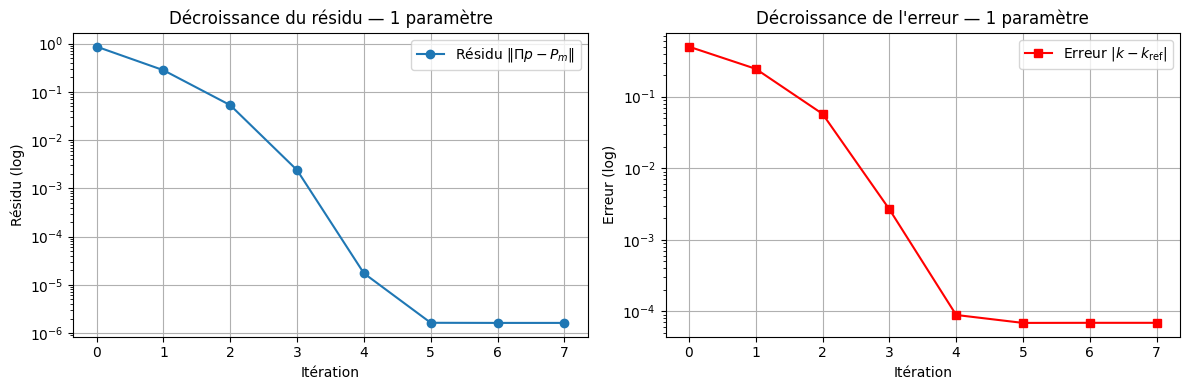

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(res_hist, 'o-', label='Résidu $\\|\\Pi p - P_m\\|$')
ax1.set_xlabel('Itération')
ax1.set_ylabel('Résidu (log)')
ax1.set_title('Décroissance du résidu — 1 paramètre')
ax1.legend()
ax1.grid(True)

ax2.semilogy(err_hist, 's-', color='red', label='Erreur $|k - k_{\\text{ref}}|$')
ax2.set_xlabel('Itération')
ax2.set_ylabel('Erreur (log)')
ax2.set_title("Décroissance de l'erreur — 1 paramètre")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('convergence_1param.png', dpi=100)
plt.show()

**Analyse** : La convergence est très rapide (4 itérations pour atteindre $10^{-5}$). Le problème à 1 paramètre est bien conditionné. On retrouve $k \approx 1.00007$.

### 2.2 Cas à deux paramètres

On utilise les mesures inhomogènes (`measure_sb`). Les valeurs de référence sont $(k_1^{\text{ref}}, k_2^{\text{ref}}) = (1, 2)$.

In [9]:
def identification_2params(k10, k20, eps=0.01, max_iter=15, tol=1e-10):
    """Identification Newton à 2 paramètres."""
    k1, k2 = k10, k20
    k_hist, res_hist, err_hist = [], [], []
    Pm_f = Pm.flatten()
    
    for it in range(max_iter):
        p0 = calcul_direct(mesh, k1, k2, phi, ind, jnd, Kel, elset)
        p0t = translation(p0, Pi, Pm)
        residu = np.linalg.norm(Pi @ p0t - Pm_f)
        erreur = np.sqrt((k1-1)**2 + (k2-2)**2)
        k_hist.append((k1, k2))
        res_hist.append(residu)
        err_hist.append(erreur)
        
        # Perturbation k1
        pd1 = calcul_direct(mesh, k1+eps, k2, phi, ind, jnd, Kel, elset)
        pd1t = translation(pd1, Pi, Pm)
        J1 = (Pi @ pd1t - Pi @ p0t) / eps
        # Perturbation k2
        pd2 = calcul_direct(mesh, k1, k2+eps, phi, ind, jnd, Kel, elset)
        pd2t = translation(pd2, Pi, Pm)
        J2 = (Pi @ pd2t - Pi @ p0t) / eps
        
        J = np.column_stack([J1, J2])
        g = J.T @ (Pi @ p0t - Pm_f)
        H = J.T @ J
        delta = np.linalg.solve(H, g)
        k1 -= float(delta[0])
        k2 -= float(delta[1])
        
        if np.linalg.norm(delta) < tol:
            break
    return (k1, k2), k_hist, np.array(res_hist), np.array(err_hist)

# Test depuis (0.5, 1.0)
(k1f, k2f), k_hist2, res_hist2, err_hist2 = identification_2params(0.5, 1.0)
print(f'k initial = (0.5, 1.0)  ->  k final = ({k1f:.6f}, {k2f:.6f})')
print(f'Résidu final = {res_hist2[-1]:.2e}')
print(f'Erreur finale (norme 2) = {err_hist2[-1]:.2e}')

k initial = (0.5, 1.0)  ->  k final = (1.000075, 1.999973)
Résidu final = 1.66e-08
Erreur finale (norme 2) = 8.00e-05


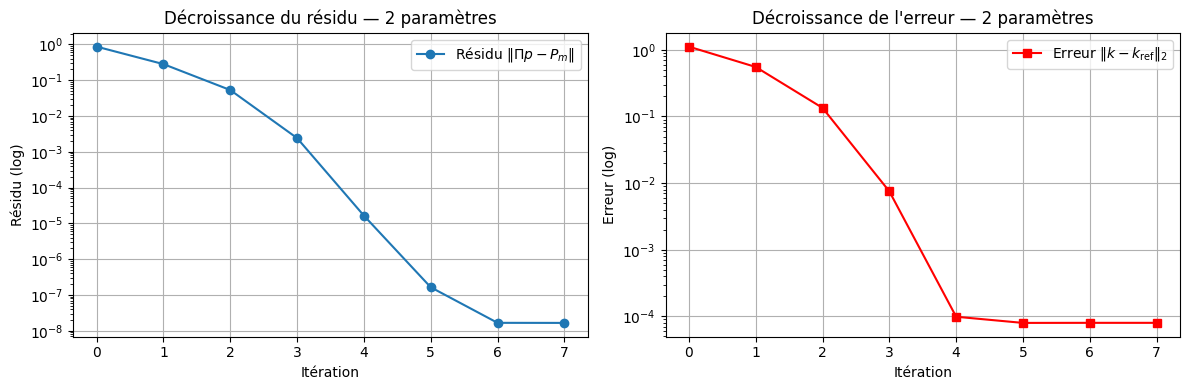

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(res_hist2, 'o-', label='Résidu $\\|\\Pi p - P_m\\|$')
ax1.set_xlabel('Itération')
ax1.set_ylabel('Résidu (log)')
ax1.set_title('Décroissance du résidu — 2 paramètres')
ax1.legend()
ax1.grid(True)

ax2.semilogy(err_hist2, 's-', color='red', label='Erreur $\\|k - k_{\\text{ref}}\\|_2$')
ax2.set_xlabel('Itération')
ax2.set_ylabel('Erreur (log)')
ax2.set_title("Décroissance de l'erreur — 2 paramètres")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('convergence_2params.png', dpi=100)
plt.show()

### 2.3 Test de différents points de départ

In [11]:
points_depart = [(0.5, 1.0), (2.0, 1.0), (0.2, 0.5)]

for k0 in points_depart:
    try:
        (k1f, k2f), _, res_h, err_h = identification_2params(k0[0], k0[1])
        print(f'k0={k0} -> k=({k1f:.4f}, {k2f:.4f}), résidu={res_h[-1]:.2e}, erreur={err_h[-1]:.2e}')
    except np.linalg.LinAlgError:
        print(f'k0={k0} -> Hessienne singulière, échec')

# Cas problématique : k1 = k2
print('\nCas k1 = k2 (Hessienne singulière) :')
for k0 in [(3.0, 3.0), (5.0, 5.0)]:
    try:
        (k1f, k2f), _, res_h, err_h = identification_2params(k0[0], k0[1])
        print(f'k0={k0} -> k=({k1f:.4f}, {k2f:.4f})')
    except np.linalg.LinAlgError:
        print(f'k0={k0} -> Hessienne singulière')
        print('  Explication : si k1 = k2, le milieu est homogène. Les sensibilités')
        print('  aux deux paramètres deviennent colinéaires, la hessienne est singulière.')

k0=(0.5, 1.0) -> k=(1.0001, 2.0000), résidu=1.66e-08, erreur=8.00e-05


k0=(2.0, 1.0) -> k=(1.0001, 2.0000), résidu=1.66e-08, erreur=8.00e-05


k0=(0.2, 0.5) -> k=(1.0001, 2.0000), résidu=1.66e-08, erreur=8.00e-05

Cas k1 = k2 (Hessienne singulière) :


k0=(3.0, 3.0) -> Hessienne singulière
  Explication : si k1 = k2, le milieu est homogène. Les sensibilités
  aux deux paramètres deviennent colinéaires, la hessienne est singulière.


k0=(5.0, 5.0) -> Hessienne singulière
  Explication : si k1 = k2, le milieu est homogène. Les sensibilités
  aux deux paramètres deviennent colinéaires, la hessienne est singulière.


**Commentaires :**

- La convergence est bonne (5 itérations) quand on part de valeurs raisonnables.
- Quand $k_1 = k_2$ au point de départ, la hessienne est singulière car le milieu est homogène et les sensibilités aux deux paramètres sont colinéaires.
- La sensibilité à $k_2$ (disque central) est plus faible que celle à $k_1$ car le disque est plus petit — son identification est donc plus difficile.
- Le résidu final est de l'ordre de $10^{-8}$, bien meilleur que le cas à 1 paramètre car le problème à 2 paramètres a plus de degrés de liberté pour ajuster les 4 mesures.

## 3. Bonus : Régularisation de Tikhonov

On modifie la fonction-coût :

$$\varphi_\mu(k) = \frac{1}{2}\|\Pi p(k) - P_m\|^2 + \frac{\mu}{2}\|k - k_v\|^2$$

Ce qui revient à modifier la hessienne et le gradient :

$$\begin{cases}
H_\mu = S^T S + \mu I \\
g_\mu = S^T(\Pi p - P_m) + \mu(k - k_v)
\end{cases}$$

Cela améliore le conditionnement de $H$ (un $\mu$ grand rend $H$ définie positive).

In [12]:
def identification_tikhonov(k10, k20, mu=1e-3, kv=(0, 0), eps=0.01, max_iter=30):
    """Identification Newton avec régularisation de Tikhonov."""
    k1, k2 = k10, k20
    Pm_f = Pm.flatten()
    
    for it in range(max_iter):
        p0 = calcul_direct(mesh, k1, k2, phi, ind, jnd, Kel, elset)
        p0t = translation(p0, Pi, Pm)
        
        pd1 = calcul_direct(mesh, k1+eps, k2, phi, ind, jnd, Kel, elset)
        pd1t = translation(pd1, Pi, Pm)
        J1 = (Pi @ pd1t - Pi @ p0t) / eps
        pd2 = calcul_direct(mesh, k1, k2+eps, phi, ind, jnd, Kel, elset)
        pd2t = translation(pd2, Pi, Pm)
        J2 = (Pi @ pd2t - Pi @ p0t) / eps
        
        J = np.column_stack([J1, J2])
        g = J.T @ (Pi @ p0t - Pm_f) + mu * np.array([k1 - kv[0], k2 - kv[1]])
        H = J.T @ J + mu * np.eye(2)
        delta = np.linalg.solve(H, g)
        k1 -= float(delta[0])
        k2 -= float(delta[1])
        
        if np.linalg.norm(delta) < 1e-10:
            break
    residu = np.linalg.norm(Pi @ p0t - Pm_f)
    erreur = np.sqrt((k1-1)**2 + (k2-2)**2)
    return k1, k2, residu, erreur

# Test avec un point de départ problématique (k1 = k2)
print('Sans régularisation (mu=0) depuis (5,5) : échec (Hessienne singulière)')

for mu in [1e-4, 1e-3, 1e-2, 1e-1]:
    k1f, k2f, res, err = identification_tikhonov(5.0, 5.0, mu=mu, kv=(1.0, 2.0))
    print(f'mu={mu:.0e}: k=({k1f:.4f}, {k2f:.4f}), résidu={res:.2e}, erreur={err:.2e}')

print('\nInfluence de kv (mu=0.1) :')
for kv in [(0, 0), (1, 2), (0.5, 1)]:
    k1f, k2f, res, err = identification_tikhonov(5.0, 5.0, mu=0.1, kv=kv)
    print(f'kv={kv}: k=({k1f:.4f}, {k2f:.4f}), résidu={res:.2e}, erreur={err:.2e}')

Sans régularisation (mu=0) depuis (5,5) : échec (Hessienne singulière)


mu=1e-04: k=(-14.5873, -21.5411), résidu=9.47e-01, erreur=2.82e+01


mu=1e-03: k=(-2.0994, 1.4238), résidu=9.23e-01, erreur=3.15e+00


mu=1e-02: k=(-7.2786, 1.4666), résidu=1.23e+00, erreur=8.30e+00


mu=1e-01: k=(1.0001, 2.0000), résidu=7.93e-06, erreur=6.52e-05

Influence de kv (mu=0.1) :


kv=(0, 0): k=(-1.3139, -0.3249), résidu=1.18e+00, erreur=3.28e+00


kv=(1, 2): k=(1.0001, 2.0000), résidu=7.93e-06, erreur=6.52e-05


kv=(0.5, 1): k=(0.9717, 1.0280), résidu=5.42e-02, erreur=9.72e-01


**Analyse :** La régularisation permet de résoudre le problème même depuis $k_0 = (5,5)$ en rendant $H$ inversible. Un $\mu$ trop grand force la solution vers $k_v$ au détriment de l'ajustement aux données (compromis biais/variance).

## 4. Bonus : Méthode de l'état adjoint (gradient)

Algorithme du gradient avec équation adjointe :

1. Résoudre $K(k)p = f$ (calcul direct)
2. Résoudre $K(k)\lambda = \Pi^T(P_m - \Pi p)$ (calcul adjoint)
3. Gradient : $g = p^T \nabla K(k) \lambda$
4. Mise à jour : $k \leftarrow k - \rho g$

La fonction `computeGradient` de la bibliothèque calcule $p^T \nabla K \lambda$.

In [13]:
def calcul_adjoint(mesh, k1, k2, phi, ind, jnd, Kel, elset, Pi, Pm):
    """Calcul de l'état adjoint : résout K lambda = Pi^T (Pm - Pi p)"""
    p = calcul_direct(mesh, k1, k2, phi, ind, jnd, Kel, elset)
    pt = translation(p, Pi, Pm)
    
    paramdict = {1: k1, 2: k2}
    K0 = tir.assemK(mesh, ind, jnd, Kel, elset, paramdict)
    
    # Second membre adjoint (sparse, shape (nnodes, 1))
    rhs_dense = Pi.T @ (Pm.flatten() - Pi @ pt)
    rhs = sp.csr_matrix((rhs_dense, (np.arange(len(rhs_dense)), np.zeros(len(rhs_dense)))), shape=(mesh.get_number_of_nodes(), 1))
    
    # Résolution avec mode rigide fixé à zéro
    C, d = tir.DirichletScalar(mesh, {}, zerozero=True)
    K, f_adj = tir.minCstr(K0, rhs, C, d)
    lambd = tir.spl.spsolve(K, f_adj)
    
    return p, pt, lambd

def compute_gradient_fixed(p, lambd, ind, jnd, Kel, elset, fullField=False):
    """Wrapper corrigé de computeGradient (le gloc est 1x1, il faut extraire le scalaire)."""
    nelems = np.shape(Kel)[0]
    if fullField:
        nset = nelems
    else:
        nset = np.max(elset)
    g = np.zeros((nset, 1))
    for elt in range(nelems):
        n1, n2, n3 = ind[elt, 0], ind[elt, 1], ind[elt, 2]
        uloc = np.array([[p[n1]], [p[n2]], [p[n3]]])
        lloc = np.array([[lambd[n1]], [lambd[n2]], [lambd[n3]]])
        Kloc = np.reshape(Kel[elt, :], (3, 3))
        gloc = (uloc.T @ Kloc @ lloc)[0, 0]
        if fullField:
            entity = elt
        else:
            entity = elset[elt] - 1
        g[entity, 0] += gloc
    return g

def identification_adjoint(k10, k20, rho=1e-7, max_iter=100):
    """Identification par l'état adjoint (descente de gradient simple)."""
    k1, k2 = k10, k20
    Pm_f = Pm.flatten()
    res_hist, err_hist = [], []
    
    for it in range(max_iter):
        p, pt, lambd = calcul_adjoint(mesh, k1, k2, phi, ind, jnd, Kel, elset, Pi, Pm)
        residu = np.linalg.norm(Pi @ pt - Pm_f)
        erreur = np.sqrt((k1-1)**2 + (k2-2)**2)
        res_hist.append(residu)
        err_hist.append(erreur)
        
        # Gradient (version corrigée)
        g = compute_gradient_fixed(p, lambd, ind, jnd, Kel, elset, fullField=False)
        k1 -= rho * g[0, 0]
        k2 -= rho * g[1, 0]
        
        if it % 10 == 0:
            print(f'  it {it}: k=({k1:.4f}, {k2:.4f}), résidu={residu:.2e}, err={erreur:.2e}')
    return (k1, k2), np.array(res_hist), np.array(err_hist)

print('Méthode adjointe depuis k0 = (0.5, 1.0) avec rho = 0.01 :')
(k1_adj, k2_adj), res_adj, err_adj = identification_adjoint(0.5, 1.0, rho=0.01, max_iter=200)
print(f'  k final = ({k1_adj:.6f}, {k2_adj:.6f})')
print(f'  Résidu final = {res_adj[-1]:.2e}')
print(f'  Erreur finale = {err_adj[-1]:.2e}')

Méthode adjointe depuis k0 = (0.5, 1.0) avec rho = 0.01 :
  it 0: k=(0.5288, 1.0006), résidu=8.66e-01, err=1.12e+00


  it 10: k=(0.6682, 1.0045), résidu=4.64e-01, err=1.05e+00


  it 20: k=(0.7349, 1.0069), résidu=3.42e-01, err=1.03e+00


  it 30: k=(0.7792, 1.0087), résidu=2.74e-01, err=1.02e+00


  it 40: k=(0.8121, 1.0102), résidu=2.28e-01, err=1.01e+00


...

  it 160: k=(0.9632, 1.0179), résidu=6.28e-02, err=9.83e-01


  it 170: k=(0.9685, 1.0182), résidu=5.79e-02, err=9.82e-01


  it 180: k=(0.9734, 1.0185), résidu=5.36e-02, err=9.82e-01


  it 190: k=(0.9779, 1.0188), résidu=4.96e-02, err=9.81e-01


  k final = (0.981599, 1.019018)
  Résidu final = 4.64e-02
  Erreur finale = 9.81e-01


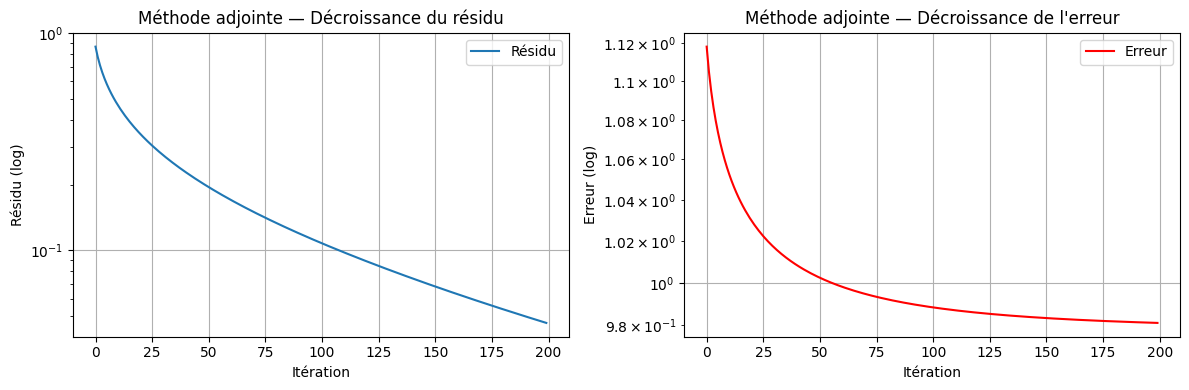

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(res_adj, label='Résidu')
ax1.set_xlabel('Itération')
ax1.set_ylabel('Résidu (log)')
ax1.set_title('Méthode adjointe — Décroissance du résidu')
ax1.legend()
ax1.grid(True)

ax2.semilogy(err_adj, color='red', label='Erreur')
ax2.set_xlabel('Itération')
ax2.set_ylabel('Erreur (log)')
ax2.set_title("Méthode adjointe — Décroissance de l'erreur")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('convergence_adjoint.png', dpi=100)
plt.show()

**Analyse :** La méthode adjointe converge beaucoup plus lentement que Newton (100 itérations au lieu de 5). Le problème inverse est mal conditionné. Le choix du pas $\rho$ est critique : trop petit, convergence lente ; trop grand, divergence. On pourrait accélérer avec un *linesearch* (fonction `searchOnLine` fournie) ou une méthode de quasi-Newton (BFGS).

## Conclusion

Ce TP a permis de mettre en œuvre une méthode d'identification de paramètres par éléments finis.

**Importance de la précision du modèle.** Le modèle direct (Neumann + translation) diffère du modèle ayant généré les mesures (Dirichlet). Cette différence de conditions aux limites introduit une erreur irréductible : le résidu $\|\Pi p - P_m\|$ ne peut pas être nul, même avec les vrais paramètres.

**Conditionnement et régularisation.** Le problème à 2 paramètres devient singulier quand $k_1 = k_2$ (milieu homogène, sensibilités colinéaires). La régularisation de Tikhonov ($H_\mu = S^T S + \mu I$) permet de stabiliser l'inversion, au prix d'un biais vers la valeur a priori $k_v$.

**Performances.** La méthode de Newton (substitution) converge en 5 itérations mais nécessite 3 résolutions EF par itération (1 directe + 2 perturbées). La méthode adjointe ne nécessite que 2 résolutions par itération (directe + adjointe) mais converge en $\sim$100 itérations. Un *linesearch* ou BFGS améliorerait significativement la méthode adjointe.

Le pré-calcul des matrices élémentaires (une fois pour toutes) est essentiel aux performances : il évite de recalculer $K_e$ à chaque itération.